In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
filepath =  'OIS daily data_2016 to 2024.xlsx'
fullCurve_sheetname = '4. spot curve'
shortEnd_sheetname = '3. spot, short end'

fullCurve = pd.read_excel(filepath, 
                          sheet_name=fullCurve_sheetname, 
                          header = 0, 
                          skiprows = [0, 1, 2, 4])

fullCurve = fullCurve.rename(columns={'years:': 'date'})
fullCurve =fullCurve.drop(0.5, axis = 1)


In [14]:
frontEnd = pd.read_excel(filepath,
                          sheet_name=shortEnd_sheetname,
                          header = 0,
                          skiprows = [0, 1, 2, 4])

frontEnd.rename(columns={'years:': 'date'}, inplace=True)

frontEnd_monthIndex = pd.read_excel(filepath,
                          sheet_name=shortEnd_sheetname,
                          header = 0,
                          skiprows = [0, 1, 4]).columns

frontEnd_monthIndex = [int(x) if type(x) != str else x for x in frontEnd_monthIndex ]
SELECT_MONTHS = [1, 2, 3, 4, 5, 6, 9, 15, 21]
frontEnd_selectedIdx = [0] + [frontEnd_monthIndex.index(x) for x in SELECT_MONTHS]
frontEnd = frontEnd.iloc[:, frontEnd_selectedIdx]
frontEnd.columns = ['date'] + [round(x/12, 4) for x in SELECT_MONTHS]

fullFrame = pd.merge(frontEnd, fullCurve, on='date', how='inner')

In [20]:
excel.sheet_names

['info', '1. fwd curve', '2. spot curve']

In [23]:
finalFrameStore = {}

SELECT_MONTHS = [1, 2, 3, 4, 5, 6, 9, 15, 21, 27, 39, 45, 51, 57]

for filename in sorted(os.listdir()):
    if not filename.endswith('.xlsx') or filename == 'OIS daily data_2009 to 2015.xlsx':
        continue
    else:
        filepath = os.path.join(filename)
        print(filename)
        excel = pd.ExcelFile(filepath)
        shortEnd_sheetname = excel.sheet_names[3]
        fullCurve_sheetname = excel.sheet_names[4]
        fullCurve = pd.read_excel(filepath, 
                                sheet_name=fullCurve_sheetname, 
                                header = 0, 
                                skiprows = [0, 1, 2, 4])
        fullCurve = fullCurve.rename(columns={'years:': 'date'})
        fullCurve =fullCurve.drop(0.5, axis = 1)

        frontEnd = pd.read_excel(filepath,
                            sheet_name=shortEnd_sheetname,
                            header = 0,
                            skiprows = [0, 1, 2, 4])
        
        frontEnd.rename(columns={'years:': 'date'}, inplace=True)
        frontEnd_monthIndex = pd.read_excel(filepath,
                            sheet_name=shortEnd_sheetname,
                            header = 0,
                            skiprows = [0, 1, 4]).columns.to_list()
        frontEnd_monthIndex = [int(x) if type(x) != str else x for x in frontEnd_monthIndex ]
        
        frontEnd_selectedIdx = [0] + [frontEnd_monthIndex.index(x) for x in SELECT_MONTHS]
        frontEnd = frontEnd.iloc[:, frontEnd_selectedIdx]
        frontEnd.columns = ['date'] + [round(x/12, 4) for x in SELECT_MONTHS]

        fullFrame = pd.merge(frontEnd, fullCurve, on='date', how='inner')
        finalFrameStore[filename] = fullFrame

        

OIS daily data_2016 to 2024.xlsx
OIS daily data_2025 to present.xlsx


In [24]:
finalDf = pd.concat(finalFrameStore.values()).set_index('date')
finalDf = finalDf.sort_index(axis=1)
finalDf

,0.0833,0.1667,0.2500,0.3333,0.4167,0.5000,0.7500,1.0000,1.2500,1.5000,...,20.5000,21.0000,21.5000,22.0000,22.5000,23.0000,23.5000,24.0000,24.5000,25.0000
date,,,,,,,,,,,,,,,,,,,,,
2016-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-04,0.462971,0.465334,0.468218,0.472246,0.477829,0.493917,0.516199,0.559152,0.627135,0.662591,...,1.939929,1.942235,1.943938,1.945104,1.945795,1.946067,1.945971,1.945556,1.944864,1.943938
2016-01-05,0.463790,0.466286,0.468429,0.471526,0.475950,0.488520,0.506153,0.542545,0.603702,0.636335,...,1.923617,1.925961,1.927701,1.928906,1.929637,1.929949,1.929894,1.929519,1.928868,1.927980
2016-01-06,0.462616,0.464768,0.466627,0.468664,0.471448,0.480401,0.494780,0.525816,0.578297,0.606796,...,1.861184,1.864355,1.866933,1.868982,1.870560,1.871720,1.872509,1.872971,1.873147,1.873073
2016-01-07,0.465327,0.466449,0.467468,0.468984,0.471211,0.478074,0.489075,0.514902,0.561968,0.588228,...,1.862850,1.866693,1.869931,1.872627,1.874840,1.876624,1.878028,1.879098,1.879876,1.880401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-25,3.740324,3.790874,3.848283,3.904476,3.957085,4.044972,4.109714,4.176747,4.227652,4.239200,...,4.744950,4.752153,4.758303,4.763426,4.767554,4.770717,4.772950,4.774288,4.774769,4.774429
2026-03-26,3.738331,3.791107,3.853696,3.917424,3.979332,4.088240,4.172838,4.261629,4.327721,4.343525,...,4.869535,4.876928,4.883291,4.888643,4.893011,4.896418,4.898892,4.900463,4.901162,4.901020
2026-03-27,3.736760,3.780960,3.836486,3.894374,3.951206,4.051240,4.128459,4.209476,4.270707,4.285736,...,4.868619,4.875428,4.881246,4.886102,4.890028,4.893051,4.895201,4.896507,4.896996,4.896699


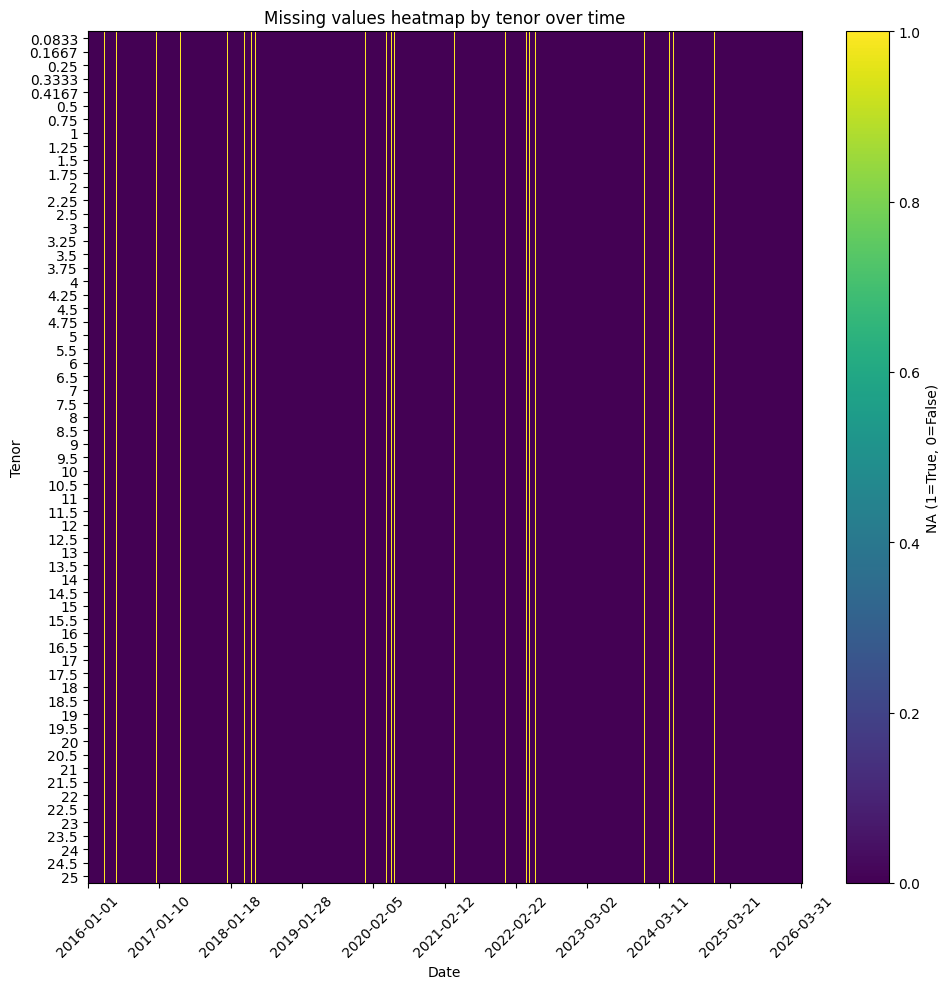

In [25]:
na_mask = finalDf.isna()

plt.figure(figsize=(10, 10))
plt.imshow(na_mask.T, aspect="auto", interpolation="nearest", cmap="viridis")
plt.colorbar(label="NA (1=True, 0=False)")

plt.yticks(range(len(finalDf.columns)), finalDf.columns)
plt.xticks(
    ticks=range(0, len(finalDf.index), max(1, len(finalDf.index)//10)),
    labels=finalDf.index[::max(1, len(finalDf.index)//10)].strftime("%Y-%m-%d"),
    rotation=45
)

plt.xlabel("Date")
plt.ylabel("Tenor")
plt.title("Missing values heatmap by tenor over time")
plt.tight_layout()
plt.show()

In [27]:
finalDf.to_csv('bankofengland_SONIA_filtered.csv')